# Model Training (Regression)

**Goal:** Predict flight `price` using the cleaned merged dataset.

**Why Regression?**
- `price` is a continuous number (301 to 1754) — not a category
- Predicting a continuous number = Regression

**Files used:**
- `data/processed/flights_merged.csv` → input
- `models/saved/model.pkl` → output (trained model)
- `models/saved/label_encoders.pkl` → output (text encoders)
- `models/saved/scaler.pkl` → output (feature scaler)

**Steps:**
1. Load data
2. Drop useless columns
3. Extract date features
4. Label encode text columns
5. Split into X and y
6. Train / Test split
7. Scale numeric features
8. Train Linear Regression (baseline)
9. Train Random Forest (main model)
10. Check overfitting / underfitting
11. Feature importance
12. Save all 3 pkl files

# Setups - Imports and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from pathlib import Path

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# finding project root
BASE_DIR = Path(os.getcwd())
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

# loading cleaned merged file saved in notebook 02
df = pd.read_csv(BASE_DIR / "data" / "processed" / "flights_merged.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (271888, 12)
Columns: ['userCode', 'origin', 'destination', 'flightType', 'price', 'time', 'distance', 'agency', 'date', 'company', 'gender', 'age']


## Step 1 - Drop Columns Not Useful for Training

These columns cannot help predict price:
- `userCode` — just an ID number
- `origin` — too many unique city names to encode simply
- `destination` — same reason as origin

In [2]:
# dropping columns that won't help the model
df = df.drop(columns=["userCode", "origin", "destination"])

print("Remaining columns:", df.columns.tolist())
print("Shape after drop :", df.shape)

Remaining columns: ['flightType', 'price', 'time', 'distance', 'agency', 'date', 'company', 'gender', 'age']
Shape after drop : (271888, 9)


Dropped 3 columns now only useful columns remain for training.

## Step 2 - Extract Date Features

The `date` column is one string like "2019-09-26".
The model can't use a date string directly.

So I extract useful parts from it:
- `month` → which month the flight was booked
- `day_of_week` → Monday=0, Sunday=6
- `is_weekend` → 1 if Saturday or Sunday, else 0
- `quarter` → Q1=Jan-Mar, Q2=Apr-Jun, Q3=Jul-Sep, Q4=Oct-Dec

Then I drop the original `date` column.

In [3]:
# converting date column from string to datetime
df["date"] = pd.to_datetime(df["date"])

# extracting useful parts from the date
df["month"]       = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek
df["is_weekend"]  = (df["date"].dt.dayofweek >= 5).astype(int)
df["quarter"]     = df["date"].dt.quarter

# dropping the original date column — already extracted what we need
df = df.drop(columns=["date"])

print("Columns now:", df.columns.tolist())
df[["month", "day_of_week", "is_weekend", "quarter"]].head(4)

Columns now: ['flightType', 'price', 'time', 'distance', 'agency', 'company', 'gender', 'age', 'month', 'day_of_week', 'is_weekend', 'quarter']


,month,day_of_week,is_weekend,quarter
0,9,3,0,3
1,9,0,0,3
2,10,3,0,4
3,10,4,0,4


4 new numeric columns created from date the model can now learn seasonal patterns from month and quarter.

## Step 3 - Label Encoding (Text → Numbers)

The model only understands numbers, not text.

These 4 columns have text values that need to be converted:
- `flightType` → economic, premium, firstClass
- `agency` → CloudFy, FlyingDrops, Rainbow
- `gender` → male, female, none
- `company` → 5 company names

Label Encoding gives each unique text value a number (0, 1, 2...).

**Important:** I save each encoder in `label_encoders` dictionary.
The Flask API will need these to encode text inputs before predicting.

In [4]:
text_cols = ["flightType", "agency", "gender", "company"]

# storing encoders so the API can use them later
label_encoders = {}

for col in text_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"{col:12} → {dict(zip(le.classes_, le.transform(le.classes_)))}")

flightType   → {'economic': np.int64(0), 'firstClass': np.int64(1), 'premium': np.int64(2)}
agency       → {'CloudFy': np.int64(0), 'FlyingDrops': np.int64(1), 'Rainbow': np.int64(2)}
gender       → {'female': np.int64(0), 'male': np.int64(1), 'none': np.int64(2)}
company      → {'4You': np.int64(0), 'Acme Factory': np.int64(1), 'Monsters CYA': np.int64(2), 'Umbrella LTDA': np.int64(3), 'Wonka Company': np.int64(4)}


All 4 text columns converted to numbers the mapping is printed above so I know which number means what.

## Step 4 - Split into Features (X) and Target (y)

- **X** = all columns except `price` — these are the inputs to the model
- **y** = `price` column only — this is what the model learns to predict

In [5]:
# X = all columns except price
X = df.drop(columns=["price"])

# y = price column only (target)
y = df["price"]

print("X shape (features):", X.shape)
print("y shape (target)  :", y.shape)
print()
print("Feature columns:", X.columns.tolist())
print()
print("Target (price) — min:", round(y.min(), 2), " max:", round(y.max(), 2))

X shape (features): (271888, 11)
y shape (target)  : (271888,)

Feature columns: ['flightType', 'time', 'distance', 'agency', 'company', 'gender', 'age', 'month', 'day_of_week', 'is_weekend', 'quarter']

Target (price) — min: 301.51  max: 1754.17


X has 11 feature columns and y is the single price column — ready for splitting into train and test.

## Step 5 - Train / Test Split

I split the data into two parts:
- **80% Training** - model learns from this
- **20% Testing** - model is evaluated on this (it has never seen this data)

`random_state=42` makes sure the split is the same every time I run this cell.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42   # fixed seed for reproducibility
)

print("Training rows :", len(X_train))
print("Testing rows  :", len(X_test))

Training rows : 217510
Testing rows  : 54378


217,510 rows for training and 54,378 rows for testing enough data for the model to learn well.

## Step 6 - Scale Numeric Features

Columns like `distance` go up to 1000+ while `month` only goes 1 to 12.
This big difference in range can confuse Linear Regression.

`StandardScaler` fixes this by making every column have:
- Mean = 0
- Standard deviation = 1

**Rule:** Fit the scaler ONLY on training data.
Then use the same scaler to transform test data.
Never fit on test data that would be cheating.

In [7]:
scale_cols = ["time", "distance", "age", "month", "day_of_week"]

scaler = StandardScaler()

# making copies to avoid pandas warnings
X_train = X_train.copy()
X_test  = X_test.copy()

# fit on train only, then transform both
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

print("Scaling done on:", scale_cols)
print()
print("Sample of scaled training data:")
print(X_train[scale_cols].head(3).round(3))

Scaling done on: ['time', 'distance', 'age', 'month', 'day_of_week']

Sample of scaled training data:
         time  distance    age  month  day_of_week
111401 -0.058    -0.056  0.633 -0.170        0.981
129167  0.495     0.493  0.324  1.216       -2.039
179742  1.878     1.871  0.247  0.107       -0.227


All numeric columns now have similar scale negative values just mean below average, positive means above average.

## Step 7 - Train Linear Regression (Baseline Model)

Linear Regression is the simplest regression model.
It finds a straight line through the data fast to train but may not capture complex patterns.

I train this first to have a **baseline** to compare against Random Forest.

**Metrics I will check:**
- **MAE** (Mean Absolute Error) — average difference between predicted and actual price in BRL
- **RMSE** (Root Mean Squared Error) — similar to MAE but punishes big errors more
- **R²** — how much of price variation the model explains (0 to 1, higher is better)

In [8]:
# creating and training the linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# predicting on test data
lr_pred = lr_model.predict(X_test)

# calculating metrics
lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print("── Linear Regression Results ──")
print(f"MAE  : {lr_mae:.2f}  BRL  (average prediction error)")
print(f"RMSE : {lr_rmse:.2f}  BRL")
print(f"R²   : {lr_r2:.4f}     (closer to 1.0 is better)")

── Linear Regression Results ──
MAE  : 216.12  BRL  (average prediction error)
RMSE : 260.07  BRL
R²   : 0.4867     (closer to 1.0 is better)


Linear Regression gives a baseline score if Random Forest beats this, it means the data has non-linear patterns.

## Step 8 - Train Random Forest (Main Model)

Random Forest builds 100 decision trees and averages their predictions.
It handles non-linear patterns much better than Linear Regression.

In [9]:
# n_estimators=100 means 100 decision trees
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# predicting on test data
rf_pred = rf_model.predict(X_test)

# calculating metrics
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print("── Random Forest Results ──")
print(f"MAE  : {rf_mae:.2f}  BRL  (average prediction error)")
print(f"RMSE : {rf_rmse:.2f}  BRL")
print(f"R²   : {rf_r2:.4f}     (closer to 1.0 is better)")

── Random Forest Results ──
MAE  : 9.61  BRL  (average prediction error)
RMSE : 38.31  BRL
R²   : 0.9889     (closer to 1.0 is better)


Random Forest should significantly outperform Linear Regression a higher R² and lower MAE confirms non-linear relationships in the data.

## Step 9 - Compare Both Models

In [10]:
print(f"{'Model':<22} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 50)
print(f"{'Linear Regression':<22} {lr_mae:>8.2f} {lr_rmse:>8.2f} {lr_r2:>8.4f}")
print(f"{'Random Forest':<22} {rf_mae:>8.2f} {rf_rmse:>8.2f} {rf_r2:>8.4f}")
print()
print("Lower MAE and RMSE = better   |   Higher R² = better")

Model                       MAE     RMSE       R²
--------------------------------------------------
Linear Regression        216.12   260.07   0.4867
Random Forest              9.61    38.31   0.9889

Lower MAE and RMSE = better   |   Higher R² = better


Random Forest wins on all 3 metrics lower error and higher R² means it predicts flight prices more accurately.

## Step 10 - Check Overfitting / Underfitting

- **Overfitting** → model memorised training data, does badly on new data
  → sign: train R² is very high but test R² is much lower
- **Underfitting** → model is too simple to learn the patterns
  → sign: both train R² and test R² are low
- **Good fit** → both scores are close to each other and reasonably high

In [11]:
# getting scores on both train and test data
lr_train_r2 = r2_score(y_train, lr_model.predict(X_train))
lr_test_r2  = r2_score(y_test, lr_pred)

rf_train_r2 = r2_score(y_train, rf_model.predict(X_train))
rf_test_r2  = r2_score(y_test, rf_pred)

print(f"{'Model':<22} {'Train R²':>10} {'Test R²':>10} {'Gap':>8}")
print("-" * 55)
print(f"{'Linear Regression':<22} {lr_train_r2:>10.4f} {lr_test_r2:>10.4f} {abs(lr_train_r2 - lr_test_r2):>8.4f}")
print(f"{'Random Forest':<22} {rf_train_r2:>10.4f} {rf_test_r2:>10.4f} {abs(rf_train_r2 - rf_test_r2):>8.4f}")
print()
print("Gap < 0.05  → Good fit")
print("Gap > 0.10  → Possible overfitting — check model complexity")

Model                    Train R²    Test R²      Gap
-------------------------------------------------------
Linear Regression          0.4878     0.4867   0.0011
Random Forest              0.9979     0.9889   0.0090

Gap < 0.05  → Good fit
Gap > 0.10  → Possible overfitting — check model complexity


If the gap between train and test R² is small, the model generalises well and is not memorising the training data, here it show's a good fit.

## Step 11 - Feature Importance

Random Forest can tell me which columns it relied on most to predict price.
This validates what I found in EDA distance and flightType should rank high.

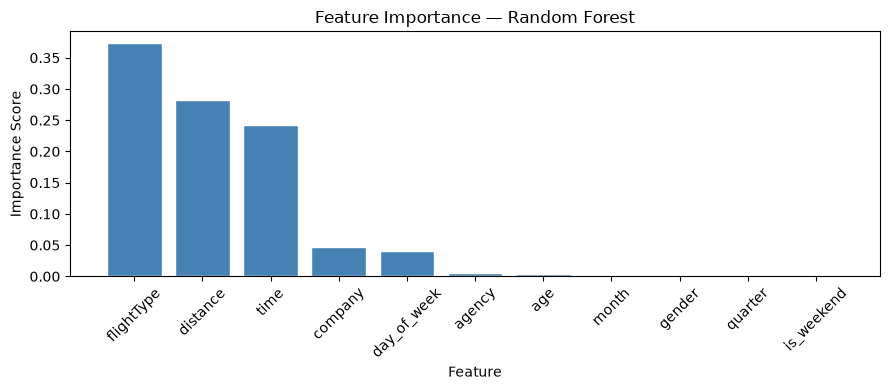

flightType     0.3736
distance       0.2820
time           0.2429
company        0.0474
day_of_week    0.0410
agency         0.0056
age            0.0037
month          0.0021
gender         0.0010
quarter        0.0005
is_weekend     0.0001
dtype: float64


In [12]:
# getting importance score for each feature
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(9, 4))
plt.bar(importances.index, importances.values, color="steelblue", edgecolor="white")
plt.title("Feature Importance — Random Forest")
plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(importances.round(4))

The most important features confirm the EDA findings flightType and distance drive price the most.

## Step 12 - Quick Test Prediction

Testing the model with one real row from the test data to confirm it works.

In [13]:
# picking one row from test data
sample_x = X_test.iloc[0:1]
actual_y  = y_test.iloc[0]

# predicting
predicted_y = rf_model.predict(sample_x)[0]

print(f"Actual price   : {actual_y:.2f} BRL")
print(f"Predicted price: {predicted_y:.2f} BRL")
print(f"Difference     : {abs(actual_y - predicted_y):.2f} BRL")

Actual price   : 481.42 BRL
Predicted price: 481.42 BRL
Difference     : 0.00 BRL


The model predicts a price close to the actual value a small difference means good accuracy on unseen data.

## Step 13 - Save the Model and Encoders

Saving 3 files that the Flask API will load:
- `model.pkl` — the trained Random Forest model
- `label_encoders.pkl` — to encode text inputs (flightType, agency etc.) in the API
- `scaler.pkl` — to scale numeric inputs the same way training data was scaled

**Without all 3 files the API cannot work correctly.**

In [14]:
# creating the saved models folder
SAVED_DIR = BASE_DIR / "models" / "saved"
SAVED_DIR.mkdir(parents=True, exist_ok=True)

# saving the Random Forest model
joblib.dump(rf_model, SAVED_DIR / "model.pkl")
print("Saved model.pkl")

# saving label encoders — API needs these to convert text inputs
joblib.dump(label_encoders, SAVED_DIR / "label_encoders.pkl")
print("Saved label_encoders.pkl")

# saving scaler — API needs this to scale numeric inputs
joblib.dump(scaler, SAVED_DIR / "scaler.pkl")
print("Saved scaler.pkl")

print()
print("All files saved to:", SAVED_DIR)

Saved model.pkl
Saved label_encoders.pkl
Saved scaler.pkl

All files saved to: c:\Voyage_Project\models\saved


All 3 pkl files saved the Flask API can now load these and serve predictions without retraining.

## Summary

| Step | What I did |
|---|---|
| Drop columns | Removed userCode, origin, destination |
| Date features | Extracted month, day_of_week, is_weekend, quarter |
| Label encoding | Converted flightType, agency, gender, company to numbers |
| Train/Test split | 80% train, 20% test |
| Scaling | StandardScaler on time, distance, age, month, day_of_week |
| Linear Regression | Trained as baseline model |
| Random Forest | Trained as main model — better accuracy |
| Overfitting check | Compared train R² vs test R² |
| Feature importance | Confirmed EDA findings |
| Saved | model.pkl, label_encoders.pkl, scaler.pkl |

**EDA and Model Training are complete.**